--- 1D Convection-Diffusion Engine Initialized ---
Grid Size: 100 Cells | cell size (dx): 0.6
Calculated Grid Peclet Number: 1.500


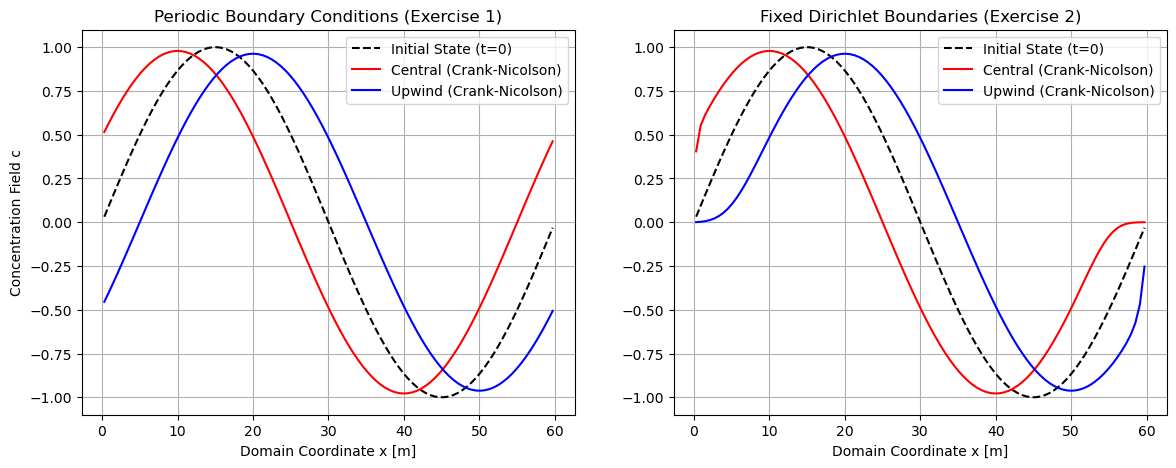


Executing Time-Step Convergence Study...


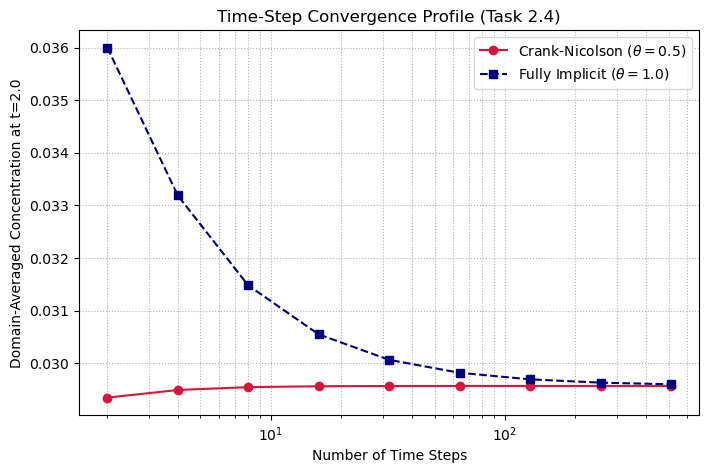

In [2]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ==============================================================================
# BLOCK 1: FINITE VOLUME MATRIX OPERATORS (GROUNDWORK FOR THE CFD ENGINE)
# ==============================================================================

def assemble_diffusion_matrix(N, dx, kappa, bc_type="periodic"):
    """
    Assembles the 1D Finite Volume Diffusion matrix.
    Stencil: kappa * (c_{i-1} - 2*c_i + c_{i+1}) / dx^2
    
    Why this structure matters for the project:
    The viscous terms in the Navier-Stokes equations follow this exact 
    Laplacian pattern.
    """
    # Main diagonal and immediate off-diagonals
    main_diag = -2.0 * np.ones(N)
    off_diag = np.ones(N - 1)
    
    # Handle modifications based on boundary conditions
    if bc_type == "periodic":
        # Periodic boundaries mean cell 0 links to cell N-1, and vice versa
        K = sp.diags([off_diag, main_diag, off_diag], [-1, 0, 1], shape=(N, N)).tolil()
        K[0, N - 1] = 1.0  # Periodic boundary wrap-around (left face of cell 0)
        K[N - 1, 0] = 1.0  # Periodic boundary wrap-around (right face of cell N-1)
    
    elif bc_type == "fixed":
        # Exercise 2A/2B: Dirichlet boundary conditions c(0) = c_0, c(L) = c_0
        # For ghost cells or face values at boundaries, we drop a half-cell gradient.
        # Boundary fluxes across the physical wall alter the edge coefficients.
        K = sp.diags([off_diag, main_diag, off_diag], [-1, 0, 1], shape=(N, N)).tolil()
        
        # Dirichlet modifications (accounting for the 3*kappa/dx^2 on edge cells)
        K[0, 0] = -3.0
        K[N - 1, N - 1] = -3.0
        
    return (kappa / dx**2) * K.tocsr()


def assemble_convection_matrix(N, dx, u, scheme="upwind", bc_type="periodic"):
    """
    Assembles the 1D Finite Volume Convection matrix.
    
    Why this choice matters for the project:
    Central differencing causes severe artificial unphysical oscillations when 
    convection dominates (high velocity currents). Upwind ensures diagonal dominance.
    """
    A = sp.lil_matrix((N, N))
    
    if scheme == "central":
        # Exercise 1A & 2A: Central approximation: (uc)_{i+1/2} = u * (c_i + c_{i+1}) / 2
        # Net flux into cell i: -u * (c_{i+1} - c_{i-1}) / (2 * dx)
        off_low = np.ones(N - 1)
        off_high = -np.ones(N - 1)
        A = sp.diags([off_low, off_high], [-1, 1], shape=(N, N)).tolil()
        
        if bc_type == "periodic":
            A[0, N - 1] = 1.0   # Wrap around from left boundary
            A[N - 1, 0] = -1.0  # Wrap around from right boundary
        elif bc_type == "fixed":
            # For fixed boundaries, the phantom boundary value is accounted for 
            # in the source/boundary vector, shifting boundary row stencils.
            A[0, 0] = -1.0
            A[N - 1, N - 1] = 1.0
            
        return (u / (2.0 * dx)) * A.tocsr()

    elif scheme == "upwind":
        # Exercise 1B & 2B: Upwind differencing. 
        # If u > 0, the face value matches the upstream neighbor cell.
        # Net flux into cell i: -u * (c_i - c_{i-1}) / dx
        if u >= 0:
            main_diag = np.ones(N)
            off_low = -np.ones(N - 1)
            A = sp.diags([off_low, main_diag], [-1, 0], shape=(N, N)).tolil()
            if bc_type == "periodic":
                A[0, N - 1] = -1.0
            elif bc_type == "fixed":
                # Boundary value is pulled from the boundary condition, modifying the left-most stencil
                A[0, 0] = 2.0  
        else:
            # If u < 0, flow moves right-to-left. Upstream is the right-hand neighbor.
            main_diag = -np.ones(N)
            off_high = np.ones(N - 1)
            A = sp.diags([main_diag, off_high], [0, 1], shape=(N, N)).tolil()
            if bc_type == "periodic":
                A[N - 1, 0] = 1.0
            elif bc_type == "fixed":
                A[N - 1, N - 1] = -2.0
                
        return (u / dx) * A.tocsr()
    else:
        raise ValueError("Unknown convective scheme type chosen.")


def build_boundary_source_vector(N, dx, kappa, u, c0, scheme, bc_type):
    """
    Constructs the boundary source vector (b_bc) to account for fixed
    Dirichlet conditions. Returns a zero vector for periodic boundaries.
    
    Why this matters for the project:
    This vector handles non-zero background current inflows at fluid inlets.
    """
    b_bc = np.zeros(N)
    if bc_type == "periodic":
        return b_bc  # Periodic boundary configurations handle fluxes implicitly via the grid wrap-around.
        
    elif bc_type == "fixed":
        # Modifications derived in Exercise 2 (Answers document)
        # Left boundary element contributions (i = 0)
        diff_left = (2.0 * kappa / dx**2) * c0
        if scheme == "central":
            conv_left = (u / dx) * c0
        elif scheme == "upwind" and u >= 0:
            conv_left = (u / dx) * c0
        else:
            conv_left = 0.0
        b_bc[0] = diff_left + conv_left
        
        # Right boundary element contributions (i = N-1)
        diff_right = (2.0 * kappa / dx**2) * c0
        if scheme == "central":
            conv_right = -(u / dx) * c0
        elif scheme == "upwind" and u < 0:
            conv_right = -(u / dx) * c0
        else:
            conv_right = 0.0
        b_bc[N - 1] = diff_right + conv_right
        
    return b_bc

# ==============================================================================
# BLOCK 2: GENERALIZED TRANSIENT TIME-STEPPING ENGINE (THE THETA-SCHEME)
# ==============================================================================

def solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt, theta, scheme, bc_type, c0=0.0):
    """
    Solves the 1D transport equation using a generalized Theta time integration scheme.
    theta = 0.0 : Explicit Forward Euler (subject to strict dt stability limits)
    theta = 0.5 : Crank-Nicolson (second-order accurate)
    theta = 1.0 : Fully Implicit Backward Euler (unconditionally stable)
    """
    dx = L / N
    x = np.linspace(dx / 2.0, L - dx / 2.0, N) # Cell-centered coordinate field
    
    # 1. Initialize concentration profile (Exercise 1 & 2 condition: c(x,0) = sin(2*pi*x/L))
    c = np.sin(2.0 * np.pi * x / L)
    
    # 2. Assemble Spatial Operator Matrices
    K = assemble_diffusion_matrix(N, dx, kappa, bc_type)
    A = assemble_convection_matrix(N, dx, u, scheme, bc_type)
    
    # Total spatial system operator: dc/dt = M * c + b_bc
    # (Note: A matrix contains the spatial convective terms)
    M = K - A
    
    # 3. Construct Boundary Forcing Vector
    b_bc = build_boundary_source_vector(N, dx, kappa, u, c0, scheme, bc_type)
    
    # 4. Formulate Theta-Scheme System Matrices
    # Equation setup: [I - theta * dt * M] * c^{n+1} = [I + (1 - theta) * dt * M] * c^n + dt * b_bc
    I = sp.eye(N, format="csr")
    LHS = I - theta * dt * M
    RHS_matrix = I + (1.0 - theta) * dt * M
    
    # Factorize Left-Hand Side matrix for fast linear solving in loops
    solve_system_step = spla.factorized(LHS)
    
    # 5. Execute Transient Evolution Loop
    t = 0.0
    while t < total_time - 1e-10:
        # Evaluate Right Hand Side vector
        b_rhs = RHS_matrix.dot(c) + dt * b_bc
        
        # Step forward in time by solving the linear system
        c = solve_system_step(b_rhs)
        t += dt
        
    return x, c

# ==============================================================================
# BLOCK 3: ANALYSIS & SIMULATION EXECUTION (EXERCISE 3 CONVERGENCE REPRODUCTION)
# ==============================================================================

if __name__ == "__main__":
    # Define physical conditions
    L = 60.0          # Domain length
    kappa = 1.0       # Diffusion coefficient
    u = 2.5           # Velocity field (convection)
    total_time = 2.0  # End evaluation time
    c0 = 0.0          # Background Dirichlet bound for fixed cases

    # Grid Resolution
    N = 100
    dx = L / N
    
    # Calculate cell Peclet Number (Pe = u * dx / kappa)
    Peclet = (u * (L / N)) / kappa
    print(f"--- 1D Convection-Diffusion Engine Initialized ---")
    print(f"Grid Size: {N} Cells | cell size (dx): {dx}")
    print(f"Calculated Grid Peclet Number: {Peclet:.3f}")
    if Peclet > 2.0:
        print("Warning: Peclet number > 2. Central Differencing may yield oscillations.")

    # --------------------------------------------------------------------------
    # SIMULATION 1: Run and Compare Schemes (Exercise 1 vs Exercise 2 Physics)
    # --------------------------------------------------------------------------
    dt_stable = 0.005  # Safe time step
    
    # Periodic Conditions (Exercise 1)
    x_p, c_central_p = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_stable, 0.5, "central", "periodic")
    _, c_upwind_p = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_stable, 0.5, "upwind", "periodic")
    
    # Fixed Dirichlet Conditions (Exercise 2)
    x_f, c_central_f = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_stable, 0.5, "central", "fixed", c0)
    _, c_upwind_f = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_stable, 0.5, "upwind", "fixed", c0)
    
    # Plot Spatial Performance Comparison Profiles
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    ax[0].plot(x_p, np.sin(2.0*np.pi*x_p/L), 'k--', label="Initial State (t=0)")
    ax[0].plot(x_p, c_central_p, 'r-', label="Central (Crank-Nicolson)")
    ax[0].plot(x_p, c_upwind_p, 'b-', label="Upwind (Crank-Nicolson)")
    ax[0].set_title("Periodic Boundary Conditions (Exercise 1)")
    ax[0].set_xlabel("Domain Coordinate x [m]")
    ax[0].set_ylabel("Concentration Field c")
    ax[0].grid(True)
    ax[0].legend()
    
    ax[1].plot(x_f, np.sin(2.0*np.pi*x_f/L), 'k--', label="Initial State (t=0)")
    ax[1].plot(x_f, c_central_f, 'r-', label="Central (Crank-Nicolson)")
    ax[1].plot(x_f, c_upwind_f, 'b-', label="Upwind (Crank-Nicolson)")
    ax[1].set_title("Fixed Dirichlet Boundaries (Exercise 2)")
    ax[1].set_xlabel("Domain Coordinate x [m]")
    ax[1].grid(True)
    ax[1].legend()
    plt.show()

    # --------------------------------------------------------------------------
    # SIMULATION 2: Time-Step Convergence Study (Replicating Task 2.4)
    # --------------------------------------------------------------------------
    print("\nExecuting Time-Step Convergence Study...")
    num_steps_list = [2, 4, 8, 16, 32, 64, 128, 256, 512]
    
    # Container lists for tracking spatial averages at end time
    explicit_averages = []
    implicit_averages = []
    
    for steps in num_steps_list:
        dt_test = total_time / steps
        
        # 1. Semi-Explicit / Crank-Nicolson (Theta = 0.5)
        # Note: If explicit conditions exceed CFL limits, this test tracks error growth
        _, c_exp = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_test, 0.5, "upwind", "fixed", c0)
        explicit_averages.append(np.average(c_exp))
        
        # 2. Fully Implicit Backward Euler (Theta = 1.0)
        _, c_imp = solve_convection_diffusion_1d(N, L, kappa, u, total_time, dt_test, 1.0, "upwind", "fixed", c0)
        implicit_averages.append(np.average(c_imp))
        
    # Generate Convergence Plots
    plt.figure(figsize=(8, 5))
    plt.plot(num_steps_list, explicit_averages, 'o-', color='crimson', label=r"Crank-Nicolson ($\theta = 0.5$)")
    plt.plot(num_steps_list, implicit_averages, 's--', color='navy', label=r"Fully Implicit ($\theta = 1.0$)")
    plt.xscale('log')
    plt.xlabel("Number of Time Steps")
    plt.ylabel("Domain-Averaged Concentration at t=2.0")
    plt.title("Time-Step Convergence Profile (Task 2.4)")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.show()